# Project 2 — House Price Prediction

**Dataset:** California Housing  
**Bài toán:** Regression — dự đoán giá nhà trung vị theo khu vực  
**Version:** 1.0 — chưa có deployment

## Mục tiêu luyện tập

Project này tập trung vào các kỹ năng:

1. Hiểu bài toán **regression**.
2. Làm **EDA** cho dữ liệu tabular.
3. Kiểm tra và xử lý **missing values**.
4. Phân tích và xử lý **outliers**.
5. Làm **feature transformation / feature engineering**.
6. Train và so sánh model:
   - Baseline model
   - Linear Regression
   - Random Forest Regressor
   - XGBoost Regressor nếu máy có cài `xgboost`
7. Đánh giá bằng regression metrics:
   - MAE
   - RMSE
   - R² Score
   - MAPE
8. Làm **error analysis** để hiểu model sai ở đâu.
9. Save model tốt nhất bằng `joblib`.

---

## Ghi chú quan trọng

California Housing trong `scikit-learn` có target là `MedHouseVal`, tức **median house value** theo đơn vị khoảng **100,000 USD**.  
Ví dụ: `2.5` nghĩa là khoảng `250,000 USD`.

# 1. Setup

Chạy cell dưới để import thư viện.  
Nếu bạn muốn dùng XGBoost nhưng máy chưa có, chạy:

```python
!pip install xgboost
```

Trong project version 1, nếu không có XGBoost thì notebook vẫn chạy được với `RandomForestRegressor`.

In [1]:
# Nếu chưa có xgboost, bỏ comment dòng dưới rồi chạy:
# !pip install xgboost

import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, KFold, cross_validate, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib

try:
    from xgboost import XGBRegressor
    XGBOOST_AVAILABLE = True
except Exception as e:
    XGBOOST_AVAILABLE = False
    print("XGBoost chưa khả dụng. Notebook sẽ bỏ qua XGBoost.")
    print("Lý do:", e)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

DATA_DIR = Path("data")
MODELS_DIR = Path("models")
REPORTS_DIR = Path("reports")

for folder in [DATA_DIR, MODELS_DIR, REPORTS_DIR]:
    folder.mkdir(exist_ok=True)

# 2. Load dataset

Ở đây dùng `fetch_california_housing()` từ `scikit-learn`.  
Dataset này phù hợp để luyện regression vì target là giá trị liên tục.

In [2]:
housing = fetch_california_housing(as_frame=True)
df = housing.frame.copy()

# Đổi tên target cho dễ hiểu hơn
df = df.rename(columns={"MedHouseVal": "target"})

print("Shape:", df.shape)
print("Features:", list(housing.feature_names))
print("Target:", housing.target_names)

df.head()

Shape: (20640, 9)
Features: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']
Target: ['MedHouseVal']


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,target
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


# 3. Data understanding

## Ý nghĩa các cột chính

- `MedInc`: median income trong block group.
- `HouseAge`: tuổi trung vị của nhà.
- `AveRooms`: số phòng trung bình.
- `AveBedrms`: số phòng ngủ trung bình.
- `Population`: dân số trong khu vực.
- `AveOccup`: số người trung bình mỗi household.
- `Latitude`, `Longitude`: tọa độ địa lý.
- `target`: median house value, đơn vị khoảng 100,000 USD.

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   Population  20640 non-null  float64
 5   AveOccup    20640 non-null  float64
 6   Latitude    20640 non-null  float64
 7   Longitude   20640 non-null  float64
 8   target      20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [4]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
MedInc,20640.0,3.870671,1.899822,0.499900,2.563400,3.534800,4.743250,15.000100
HouseAge,20640.0,28.639486,12.585558,1.000000,18.000000,29.000000,37.000000,52.000000
AveRooms,20640.0,5.429000,2.474173,0.846154,4.440716,5.229129,6.052381,141.909091
AveBedrms,20640.0,1.096675,0.473911,0.333333,1.006079,1.048780,1.099526,34.066667
Population,20640.0,1425.476744,1132.462122,3.000000,787.000000,1166.000000,1725.000000,35682.000000
AveOccup,20640.0,3.070655,10.386050,0.692308,2.429741,2.818116,3.282261,1243.333333
Latitude,20640.0,35.631861,2.135952,32.540000,33.930000,34.260000,37.710000,41.950000
Longitude,20640.0,-119.569704,2.003532,-124.350000,-121.800000,-118.490000,-118.010000,-114.310000
target,20640.0,2.068558,1.153956,0.149990,1.196000,1.797000,2.647250,5.000010


# 4. Missing values

California Housing thường không có missing values, nhưng project thực tế vẫn nên kiểm tra.  
Trong pipeline bên dưới ta vẫn dùng `SimpleImputer(strategy="median")` để code có tính thực chiến hơn.

In [5]:
missing_df = pd.DataFrame({
    "missing_count": df.isna().sum(),
    "missing_percent": df.isna().mean() * 100
}).sort_values("missing_count", ascending=False)

missing_df

,missing_count,missing_percent
MedInc,0,0.0
HouseAge,0,0.0
AveRooms,0,0.0
AveBedrms,0,0.0
Population,0,0.0
AveOccup,0,0.0
Latitude,0,0.0
Longitude,0,0.0
target,0,0.0


# 5. EDA — Exploratory Data Analysis

Ở phần này ta quan sát:

- Phân phối của target.
- Phân phối của từng feature.
- Correlation giữa các biến.
- Vị trí địa lý ảnh hưởng đến giá nhà như thế nào.

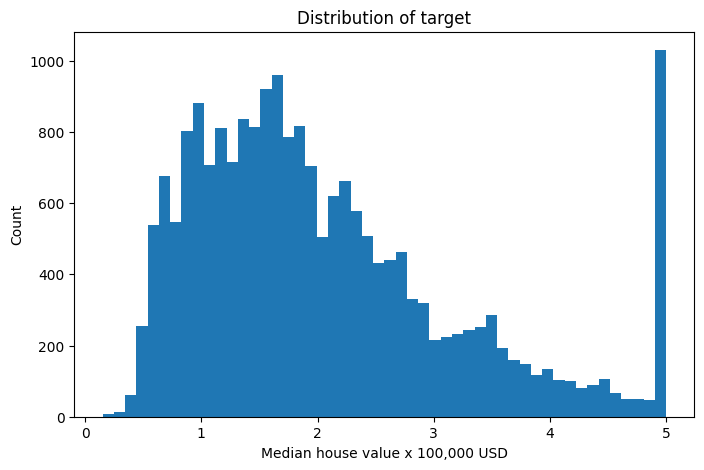

In [6]:
plt.figure(figsize=(8, 5))
plt.hist(df["target"], bins=50)
plt.xlabel("Median house value x 100,000 USD")
plt.ylabel("Count")
plt.title("Distribution of target")
plt.show()

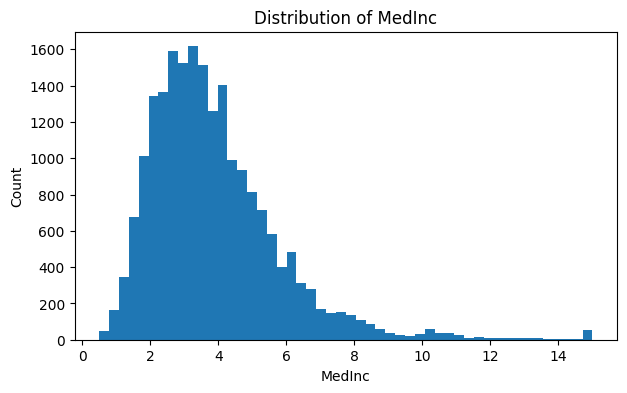

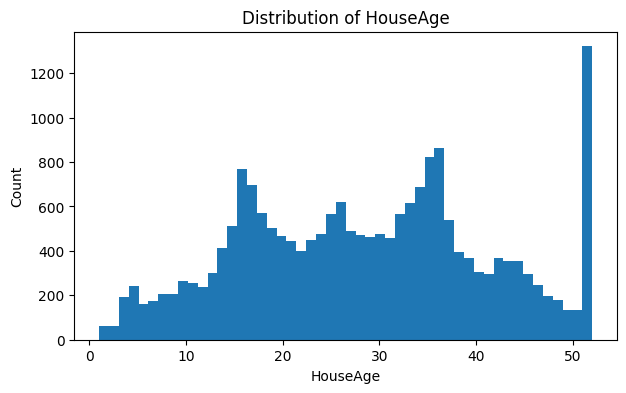

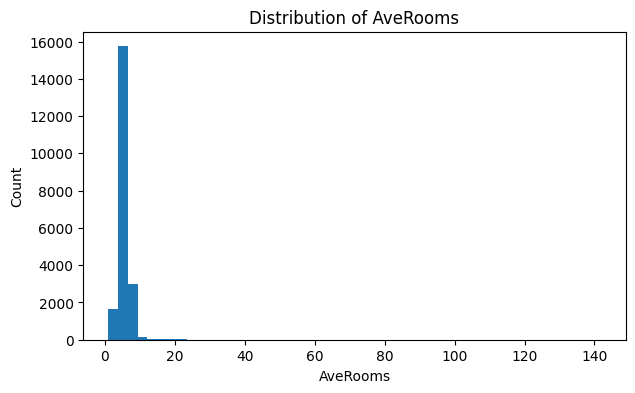

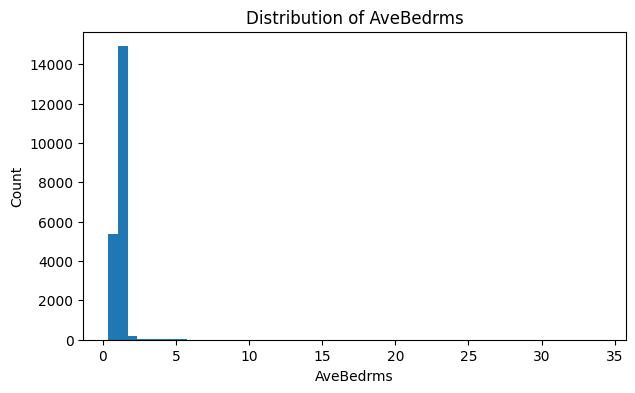

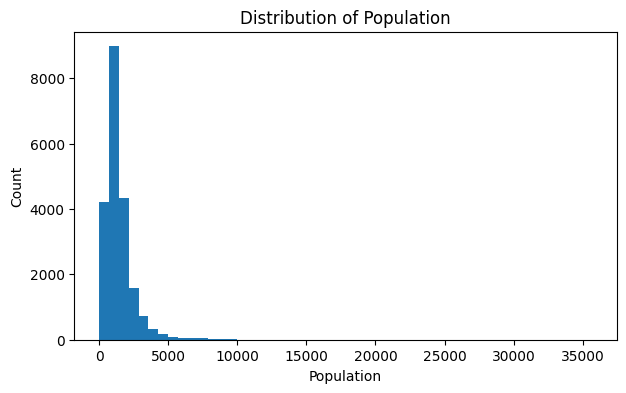

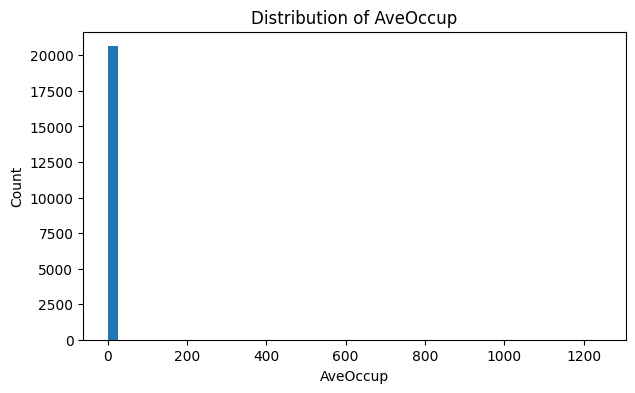

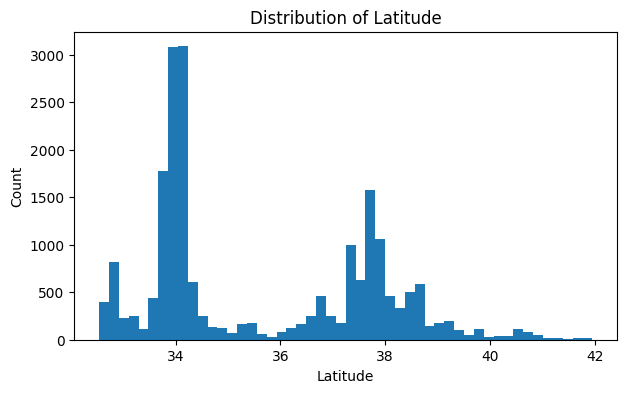

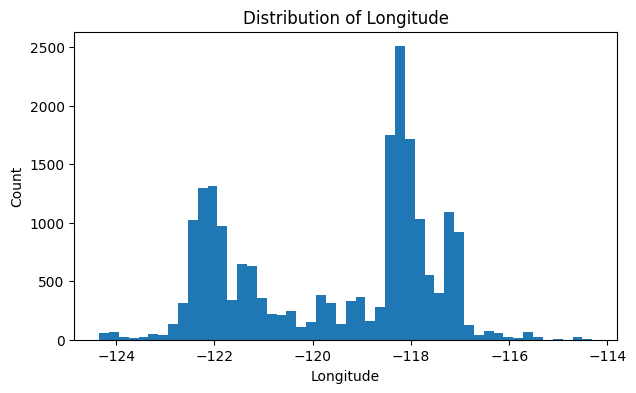

In [7]:
features = df.drop(columns="target").columns

for col in features:
    plt.figure(figsize=(7, 4))
    plt.hist(df[col], bins=50)
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.title(f"Distribution of {col}")
    plt.show()

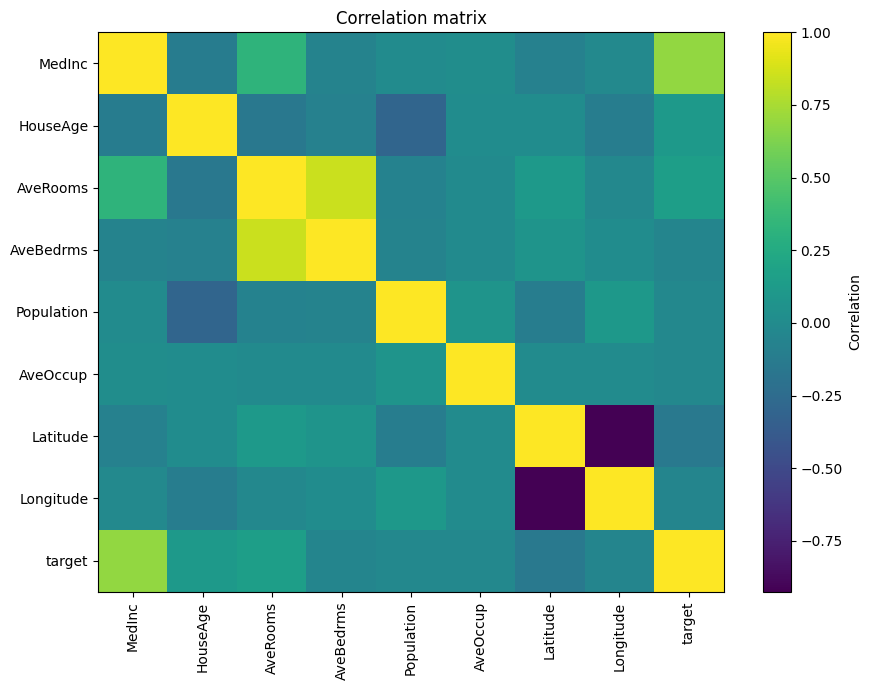

target        1.000000
MedInc        0.688075
AveRooms      0.151948
HouseAge      0.105623
AveOccup     -0.023737
Population   -0.024650
Longitude    -0.045967
AveBedrms    -0.046701
Latitude     -0.144160
Name: target, dtype: float64

In [8]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(9, 7))
plt.imshow(corr, aspect="auto")
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.index)), corr.index)
plt.colorbar(label="Correlation")
plt.title("Correlation matrix")
plt.tight_layout()
plt.show()

corr["target"].sort_values(ascending=False)

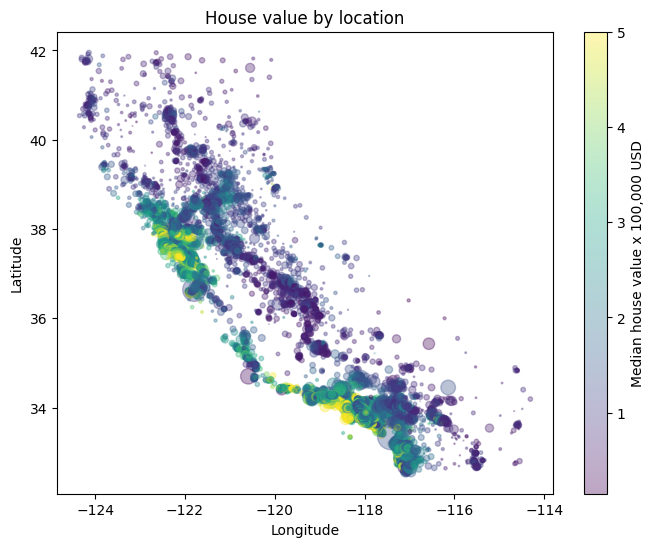

In [9]:
plt.figure(figsize=(8, 6))
scatter = plt.scatter(
    df["Longitude"],
    df["Latitude"],
    c=df["target"],
    s=df["Population"] / 100,
    alpha=0.35
)
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("House value by location")
plt.colorbar(scatter, label="Median house value x 100,000 USD")
plt.show()

# 6. Outlier analysis

**Outlier** là điểm dữ liệu bất thường.  
Trong regression, outlier có thể làm model học lệch, đặc biệt với Linear Regression và MSE/RMSE.

Ở đây ta dùng quy tắc **IQR**:

$$
IQR = Q3 - Q1
$$

Một điểm được xem là outlier nếu:

$$
x < Q1 - 1.5 \times IQR
$$

hoặc

$$
x > Q3 + 1.5 \times IQR
$$

In [10]:
def outlier_summary_iqr(dataframe, columns):
    rows = []
    for col in columns:
        q1 = dataframe[col].quantile(0.25)
        q3 = dataframe[col].quantile(0.75)
        iqr = q3 - q1
        lower = q1 - 1.5 * iqr
        upper = q3 + 1.5 * iqr
        mask = (dataframe[col] < lower) | (dataframe[col] > upper)
        rows.append({
            "feature": col,
            "lower_bound": lower,
            "upper_bound": upper,
            "outlier_count": int(mask.sum()),
            "outlier_percent": round(mask.mean() * 100, 2)
        })
    return pd.DataFrame(rows).sort_values("outlier_percent", ascending=False)

outlier_summary = outlier_summary_iqr(df, df.columns)
outlier_summary

,feature,lower_bound,upper_bound,outlier_count,outlier_percent
3,AveBedrms,0.865909,1.239697,1424,6.90
4,Population,-620.000000,3132.000000,1196,5.79
8,target,-0.980875,4.824125,1071,5.19
5,AveOccup,1.150961,4.561041,711,3.44
0,MedInc,-0.706375,8.013025,681,3.30
2,AveRooms,2.023219,8.469878,511,2.48
1,HouseAge,-10.500000,65.500000,0,0.00
6,Latitude,28.260000,43.380000,0,0.00
7,Longitude,-127.485000,-112.325000,0,0.00


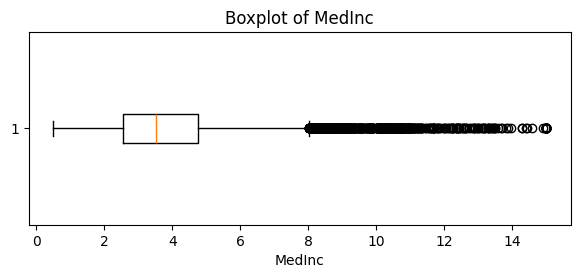

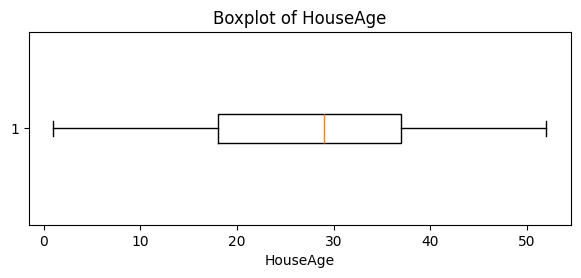

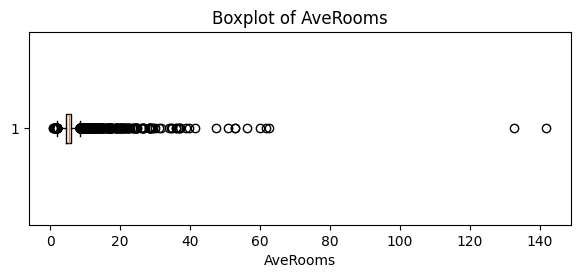

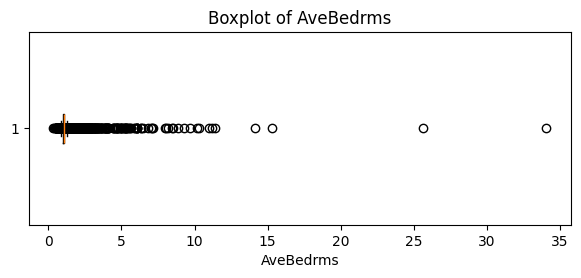

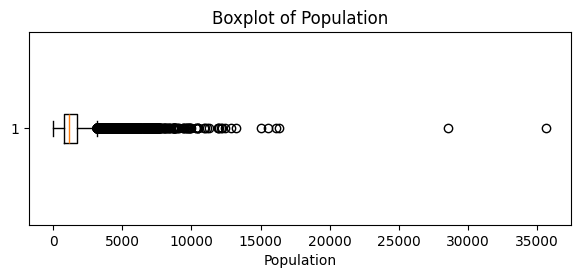

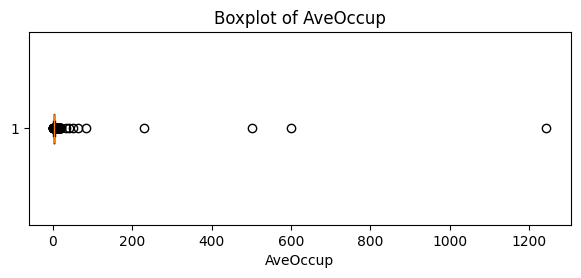

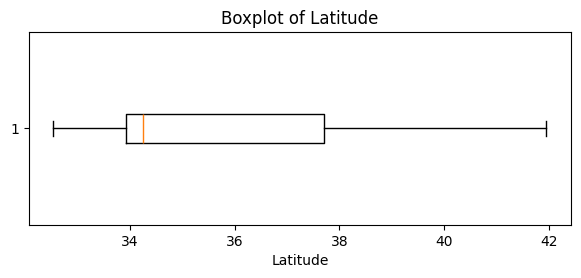

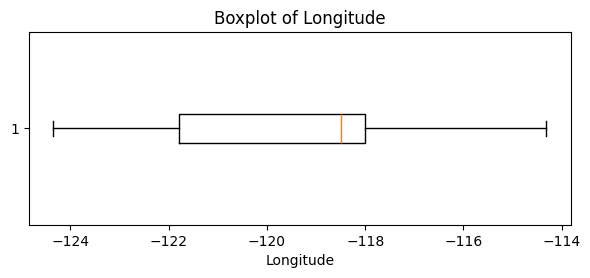

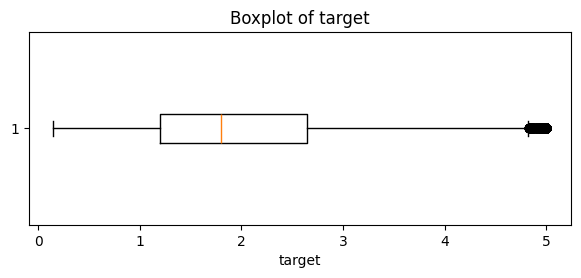

In [11]:
for col in df.columns:
    plt.figure(figsize=(7, 2.5))
    plt.boxplot(df[col], vert=False)
    plt.xlabel(col)
    plt.title(f"Boxplot of {col}")
    plt.show()

## Cách xử lý outliers trong project này

Ta sẽ không xóa dòng dữ liệu ngay vì xóa có thể làm mất thông tin địa lý thật.  
Thay vào đó, ta dùng kỹ thuật **clipping / winsorization** trong pipeline:

- Giá trị quá nhỏ sẽ được kéo về ngưỡng quantile thấp.
- Giá trị quá lớn sẽ được kéo về ngưỡng quantile cao.

Ví dụ dùng khoảng `1%` đến `99%`.

# 7. Feature engineering & transformation

Ta tạo thêm một số feature mới:

- `BedroomsPerRoom = AveBedrms / AveRooms`
- `RoomsPerPerson = AveRooms / AveOccup`
- `LogPopulation = log1p(Population)`
- `LogAveOccup = log1p(AveOccup)`
- `DistanceToSF`: khoảng cách xấp xỉ tới San Francisco theo latitude/longitude.
- `DistanceToLA`: khoảng cách xấp xỉ tới Los Angeles theo latitude/longitude.

Các feature này không chắc chắn luôn làm model tốt hơn, nhưng rất hợp để luyện **feature transformation**.

In [12]:
class FeatureEngineer(BaseEstimator, TransformerMixin):
    """Tạo feature mới cho California Housing.

    Transformer này nhận vào DataFrame và trả về DataFrame.
    Dùng được trong sklearn Pipeline.
    """

    def fit(self, X, y=None):
        self.input_features_ = list(X.columns) if hasattr(X, "columns") else None
        return self

    def transform(self, X):
        X = pd.DataFrame(X, columns=self.input_features_) if not hasattr(X, "columns") else X.copy()

        eps = 1e-6
        X["BedroomsPerRoom"] = X["AveBedrms"] / (X["AveRooms"] + eps)
        X["RoomsPerPerson"] = X["AveRooms"] / (X["AveOccup"] + eps)
        X["LogPopulation"] = np.log1p(X["Population"])
        X["LogAveOccup"] = np.log1p(X["AveOccup"])

        # Khoảng cách xấp xỉ theo tọa độ, không phải khoảng cách km chính xác.
        sf_lat, sf_lon = 37.7749, -122.4194
        la_lat, la_lon = 34.0522, -118.2437
        X["DistanceToSF"] = np.sqrt((X["Latitude"] - sf_lat) ** 2 + (X["Longitude"] - sf_lon) ** 2)
        X["DistanceToLA"] = np.sqrt((X["Latitude"] - la_lat) ** 2 + (X["Longitude"] - la_lon) ** 2)

        return X


class OutlierClipper(BaseEstimator, TransformerMixin):
    """Clip numeric features theo quantile để giảm ảnh hưởng của outlier."""

    def __init__(self, lower_quantile=0.01, upper_quantile=0.99):
        self.lower_quantile = lower_quantile
        self.upper_quantile = upper_quantile

    def fit(self, X, y=None):
        X_df = pd.DataFrame(X).copy()
        self.columns_ = X_df.columns
        self.lower_bounds_ = X_df.quantile(self.lower_quantile)
        self.upper_bounds_ = X_df.quantile(self.upper_quantile)
        return self

    def transform(self, X):
        X_df = pd.DataFrame(X, columns=self.columns_).copy()
        X_df = X_df.clip(lower=self.lower_bounds_, upper=self.upper_bounds_, axis=1)
        return X_df

In [13]:
# Test thử FeatureEngineer
feature_engineer = FeatureEngineer()
df_fe = feature_engineer.fit_transform(df.drop(columns="target"))
print("Before:", df.drop(columns="target").shape)
print("After:", df_fe.shape)
df_fe.head()

Before: (20640, 8)
After: (20640, 14)


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,BedroomsPerRoom,RoomsPerPerson,LogPopulation,LogAveOccup,DistanceToSF,DistanceToLA
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,0.146591,2.732918,5.777652,1.268511,0.216606,5.526540
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,0.155797,2.956683,7.784057,1.134572,0.216800,5.505479
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,0.129516,2.957660,6.208590,1.335596,0.194485,5.513048
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,0.184458,2.283153,6.326149,1.266369,0.185301,5.520301
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,0.172096,2.879645,6.338594,1.157342,0.185301,5.520301


# 8. Train/test split

Ta tách dữ liệu thành:

- `train`: dùng để huấn luyện model.
- `test`: giữ lại đến cuối để đánh giá công bằng.

Lưu ý: Không dùng test set để tuning quá nhiều, vì dễ bị **data leakage** hoặc đánh giá quá lạc quan.

In [14]:
X = df.drop(columns="target")
y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (16512, 8)
X_test: (4128, 8)
y_train: (16512,)
y_test: (4128,)


# 9. Evaluation metrics cho regression

Các metric chính:

## MAE — Mean Absolute Error
Sai số tuyệt đối trung bình. Dễ hiểu vì cùng đơn vị với target.

$$
MAE = \frac{1}{n}\sum |y_i - \hat{y_i}|
$$

## RMSE — Root Mean Squared Error
Phạt lỗi lớn mạnh hơn MAE.

$$
RMSE = \sqrt{\frac{1}{n}\sum (y_i - \hat{y_i})^2}
$$

## R² Score
Đo model giải thích được bao nhiêu phần biến thiên của target.

- Gần `1`: tốt.
- Gần `0`: tương đương dự đoán trung bình.
- Nhỏ hơn `0`: tệ hơn baseline trung bình.

## MAPE — Mean Absolute Percentage Error
Sai số phần trăm trung bình. Không phải lúc nào cũng ổn nếu target có giá trị gần 0.

In [15]:
def regression_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)

    # Tránh chia cho 0
    eps = 1e-8
    mape = np.mean(np.abs((y_true - y_pred) / np.maximum(np.abs(y_true), eps))) * 100

    return {
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2,
        "MAPE_%": mape
    }


def evaluate_model(name, model, X_train, y_train, X_test, y_test):
    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)

    train_metrics = regression_metrics(y_train, train_pred)
    test_metrics = regression_metrics(y_test, test_pred)

    row = {"model": name}
    for k, v in train_metrics.items():
        row[f"train_{k}"] = v
    for k, v in test_metrics.items():
        row[f"test_{k}"] = v

    return row

# 10. Build pipelines

Ta dùng `Pipeline` để đảm bảo tất cả preprocessing chỉ fit trên train data, sau đó apply lên test data.

Điều này giúp tránh **data leakage**.

In [16]:
linear_pipeline = Pipeline(steps=[
    ("features", FeatureEngineer()),
    ("outliers", OutlierClipper(lower_quantile=0.01, upper_quantile=0.99)),
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", LinearRegression())
])

rf_pipeline = Pipeline(steps=[
    ("features", FeatureEngineer()),
    ("outliers", OutlierClipper(lower_quantile=0.01, upper_quantile=0.99)),
    ("imputer", SimpleImputer(strategy="median")),
    ("model", RandomForestRegressor(
        n_estimators=200,
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
])

baseline_pipeline = Pipeline(steps=[
    ("model", DummyRegressor(strategy="median"))
])

models = {
    "Baseline_Median": baseline_pipeline,
    "LinearRegression": linear_pipeline,
    "RandomForest": rf_pipeline,
}

if XGBOOST_AVAILABLE:
    xgb_pipeline = Pipeline(steps=[
        ("features", FeatureEngineer()),
        ("outliers", OutlierClipper(lower_quantile=0.01, upper_quantile=0.99)),
        ("imputer", SimpleImputer(strategy="median")),
        ("model", XGBRegressor(
            objective="reg:squarederror",
            n_estimators=300,
            learning_rate=0.05,
            max_depth=6,
            subsample=0.9,
            colsample_bytree=0.9,
            random_state=RANDOM_STATE,
            n_jobs=-1,
            tree_method="hist"
        ))
    ])
    models["XGBoost"] = xgb_pipeline
else:
    # Fallback nếu chưa cài xgboost
    hgb_pipeline = Pipeline(steps=[
        ("features", FeatureEngineer()),
        ("outliers", OutlierClipper(lower_quantile=0.01, upper_quantile=0.99)),
        ("imputer", SimpleImputer(strategy="median")),
        ("model", HistGradientBoostingRegressor(random_state=RANDOM_STATE))
    ])
    models["HistGradientBoosting_Fallback"] = hgb_pipeline

models

{'Baseline_Median': Pipeline(steps=[('model', DummyRegressor(strategy='median'))]),
 'LinearRegression': Pipeline(steps=[('features', FeatureEngineer()), ('outliers', OutlierClipper()),
                 ('imputer', SimpleImputer(strategy='median')),
                 ('scaler', StandardScaler()), ('model', LinearRegression())]),
 'RandomForest': Pipeline(steps=[('features', FeatureEngineer()), ('outliers', OutlierClipper()),
                 ('imputer', SimpleImputer(strategy='median')),
                 ('model',
                  RandomForestRegressor(n_estimators=200, n_jobs=-1,
                                        random_state=42))]),
 'XGBoost': Pipeline(steps=[('features', FeatureEngineer()), ('outliers', OutlierClipper()),
                 ('imputer', SimpleImputer(strategy='median')),
                 ('model',
                  XGBRegressor(base_score=None, booster=None, callbacks=None,
                               colsample_bylevel=None, colsample_bynode=None,
           

# 11. Cross-validation

Cross-validation giúp đánh giá model ổn định hơn thay vì chỉ phụ thuộc một lần train/test split.

Ở đây dùng `KFold(n_splits=3)` để chạy nhanh hơn. Khi máy mạnh hơn, có thể tăng lên `5`.

In [17]:
cv = KFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

cv_rows = []
for name, model in models.items():
    print(f"Running CV for {name}...")
    scores = cross_validate(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring={
            "rmse": "neg_root_mean_squared_error",
            "mae": "neg_mean_absolute_error",
            "r2": "r2"
        },
        n_jobs=-1,
        return_train_score=False
    )
    cv_rows.append({
        "model": name,
        "cv_RMSE_mean": -scores["test_rmse"].mean(),
        "cv_RMSE_std": scores["test_rmse"].std(),
        "cv_MAE_mean": -scores["test_mae"].mean(),
        "cv_R2_mean": scores["test_r2"].mean(),
    })

cv_results = pd.DataFrame(cv_rows).sort_values("cv_RMSE_mean")
cv_results

Running CV for Baseline_Median...
Running CV for LinearRegression...
Running CV for RandomForest...
Running CV for XGBoost...


,model,cv_RMSE_mean,cv_RMSE_std,cv_MAE_mean,cv_R2_mean
3,XGBoost,0.453205,0.005795,0.298442,0.846290
2,RandomForest,0.498361,0.004325,0.322943,0.814114
1,LinearRegression,0.628503,0.010135,0.455030,0.704408
0,Baseline_Median,1.187843,0.010400,0.885992,-0.055578


# 12. Train models và so sánh trên test set

Bây giờ ta fit từng model trên toàn bộ train set và đánh giá trên test set.

In [18]:
fitted_models = {}
results = []

for name, model in models.items():
    print(f"Training {name}...")
    model.fit(X_train, y_train)
    fitted_models[name] = model
    results.append(evaluate_model(name, model, X_train, y_train, X_test, y_test))

results_df = pd.DataFrame(results).sort_values("test_RMSE")
results_df

Training Baseline_Median...
Training LinearRegression...
Training RandomForest...
Training XGBoost...


,model,train_MAE,train_RMSE,train_R2,train_MAPE_%,test_MAE,test_RMSE,test_R2,test_MAPE_%
3,XGBoost,0.216849,0.310819,0.927730,12.241386,0.291889,0.449206,0.846013,16.684754
2,RandomForest,0.114674,0.179289,0.975954,6.323729,0.310091,0.485934,0.819803,17.569435
1,LinearRegression,0.454360,0.627765,0.705195,27.390566,0.464384,0.642589,0.684892,28.380846
0,Baseline_Median,0.885918,1.188087,-0.055935,52.596634,0.874040,1.173117,-0.050209,53.104354


# 13. Hyperparameter tuning

Ta tuning model mạnh nhất trong nhóm tree-based.

Version 1 dùng `RandomizedSearchCV` để chạy nhanh.  
Nếu máy yếu, bạn có thể giảm `n_iter`. Nếu máy mạnh, tăng `n_iter` để tìm tốt hơn.

In [19]:
DO_TUNING = True

if DO_TUNING:
    rf_param_dist = {
        "model__n_estimators": [100, 200, 300],
        "model__max_depth": [None, 10, 20, 30],
        "model__min_samples_split": [2, 5, 10],
        "model__min_samples_leaf": [1, 2, 4],
        "model__max_features": ["sqrt", "log2", 1.0]
    }

    rf_search = RandomizedSearchCV(
        estimator=rf_pipeline,
        param_distributions=rf_param_dist,
        n_iter=10,
        scoring="neg_root_mean_squared_error",
        cv=3,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbose=1
    )

    rf_search.fit(X_train, y_train)

    print("Best RandomForest params:")
    print(rf_search.best_params_)
    print("Best CV RMSE:", -rf_search.best_score_)

    fitted_models["RandomForest_Tuned"] = rf_search.best_estimator_
    results.append(evaluate_model("RandomForest_Tuned", rf_search.best_estimator_, X_train, y_train, X_test, y_test))

    if XGBOOST_AVAILABLE:
        xgb_param_dist = {
            "model__n_estimators": [200, 300, 500],
            "model__max_depth": [3, 5, 7],
            "model__learning_rate": [0.01, 0.05, 0.1],
            "model__subsample": [0.8, 0.9, 1.0],
            "model__colsample_bytree": [0.8, 0.9, 1.0],
            "model__reg_lambda": [1, 5, 10]
        }

        xgb_search = RandomizedSearchCV(
            estimator=xgb_pipeline,
            param_distributions=xgb_param_dist,
            n_iter=10,
            scoring="neg_root_mean_squared_error",
            cv=3,
            random_state=RANDOM_STATE,
            n_jobs=-1,
            verbose=1
        )

        xgb_search.fit(X_train, y_train)

        print("Best XGBoost params:")
        print(xgb_search.best_params_)
        print("Best CV RMSE:", -xgb_search.best_score_)

        fitted_models["XGBoost_Tuned"] = xgb_search.best_estimator_
        results.append(evaluate_model("XGBoost_Tuned", xgb_search.best_estimator_, X_train, y_train, X_test, y_test))

results_df = pd.DataFrame(results).sort_values("test_RMSE")
results_df

Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best RandomForest params:
{'model__n_estimators': 100, 'model__min_samples_split': 2, 'model__min_samples_leaf': 2, 'model__max_features': 'sqrt', 'model__max_depth': None}
Best CV RMSE: 0.4829808223975222
Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best XGBoost params:
{'model__subsample': 0.9, 'model__reg_lambda': 5, 'model__n_estimators': 300, 'model__max_depth': 7, 'model__learning_rate': 0.05, 'model__colsample_bytree': 0.8}
Best CV RMSE: 0.4489048871368147


,model,train_MAE,train_RMSE,train_R2,train_MAPE_%,test_MAE,test_RMSE,test_R2,test_MAPE_%
5,XGBoost_Tuned,0.190796,0.279407,0.941600,10.804225,0.283664,0.437373,0.854019,16.174817
3,XGBoost,0.216849,0.310819,0.927730,12.241386,0.291889,0.449206,0.846013,16.684754
4,RandomForest_Tuned,0.151643,0.241667,0.956311,8.515473,0.309854,0.475187,0.827686,17.671017
2,RandomForest,0.114674,0.179289,0.975954,6.323729,0.310091,0.485934,0.819803,17.569435
1,LinearRegression,0.454360,0.627765,0.705195,27.390566,0.464384,0.642589,0.684892,28.380846
0,Baseline_Median,0.885918,1.188087,-0.055935,52.596634,0.874040,1.173117,-0.050209,53.104354


# 14. Chọn best model

Tiêu chí chính trong notebook này là **test RMSE thấp nhất**.  
Nhưng khi phân tích thật, bạn cũng nên nhìn MAE, R² và độ overfitting giữa train/test.

In [20]:
best_model_name = results_df.iloc[0]["model"]
best_model = fitted_models[best_model_name]

print("Best model:", best_model_name)
results_df.iloc[0]

Best model: XGBoost_Tuned


model           XGBoost_Tuned
train_MAE            0.190796
train_RMSE           0.279407
train_R2               0.9416
train_MAPE_%        10.804225
test_MAE             0.283664
test_RMSE            0.437373
test_R2              0.854019
test_MAPE_%         16.174817
Name: 5, dtype: object

# 15. Error analysis

Error analysis giúp trả lời câu hỏi:

> Model sai ở đâu? Sai nhiều với nhóm nhà rẻ, nhà đắt, hay khu vực nào?

Ta sẽ xem:

1. Residual distribution.
2. Actual vs predicted plot.
3. Top cases model sai nhiều nhất.
4. Error theo từng price bin.
5. Error theo vị trí địa lý.

In [21]:
y_pred = best_model.predict(X_test)
error_df = X_test.copy()
error_df["actual"] = y_test.values
error_df["predicted"] = y_pred
error_df["error"] = error_df["actual"] - error_df["predicted"]
error_df["abs_error"] = error_df["error"].abs()

error_df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,actual,predicted,error,abs_error
20046,1.6812,25.0,4.192201,1.022284,1392.0,3.877437,36.06,-119.01,0.47700,0.533404,-0.056404,0.056404
3024,2.5313,30.0,5.039384,1.193493,1565.0,2.679795,35.14,-119.46,0.45800,0.920393,-0.462393,0.462393
15663,3.4801,52.0,3.977155,1.185877,1310.0,1.360332,37.80,-122.44,5.00001,4.949245,0.050765,0.050765
20484,5.7376,17.0,6.163636,1.020202,1705.0,3.444444,34.28,-118.72,2.18600,2.421743,-0.235743,0.235743
9814,3.7250,34.0,5.492991,1.028037,1063.0,2.483645,36.62,-121.93,2.78000,2.175328,0.604672,0.604672


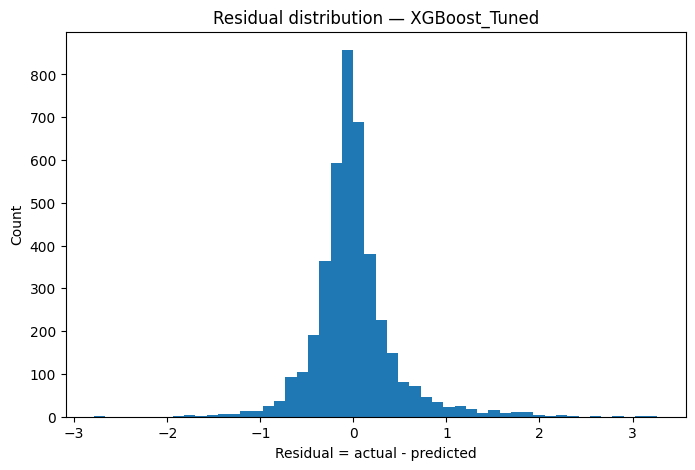

In [22]:
plt.figure(figsize=(8, 5))
plt.hist(error_df["error"], bins=50)
plt.xlabel("Residual = actual - predicted")
plt.ylabel("Count")
plt.title(f"Residual distribution — {best_model_name}")
plt.show()

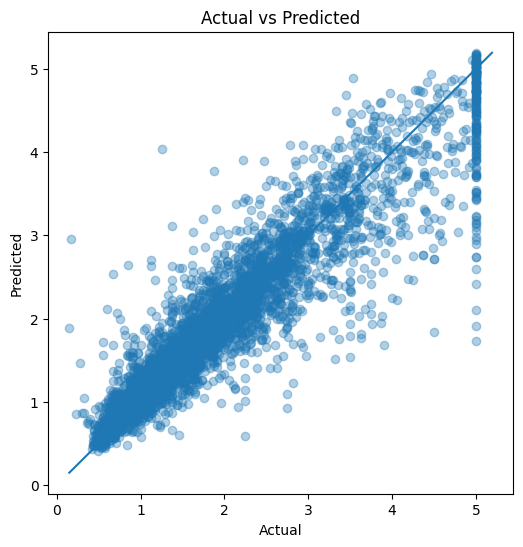

In [23]:
plt.figure(figsize=(6, 6))
plt.scatter(error_df["actual"], error_df["predicted"], alpha=0.35)
min_val = min(error_df["actual"].min(), error_df["predicted"].min())
max_val = max(error_df["actual"].max(), error_df["predicted"].max())
plt.plot([min_val, max_val], [min_val, max_val])
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted")
plt.show()

In [24]:
worst_predictions = error_df.sort_values("abs_error", ascending=False).head(20)
worst_predictions[["actual", "predicted", "error", "abs_error", "MedInc", "HouseAge", "AveRooms", "AveOccup", "Latitude", "Longitude"]]

,actual,predicted,error,abs_error,MedInc,HouseAge,AveRooms,AveOccup,Latitude,Longitude
6688,5.00001,1.731679,3.268331,3.268331,0.4999,28.0,7.677419,4.580645,34.15,-118.08
12389,5.00001,1.907999,3.092011,3.092011,3.7727,24.0,10.953586,1.995781,33.75,-116.43
12069,5.00001,2.099695,2.900315,2.900315,4.2386,6.0,7.723077,3.507692,33.83,-117.55
20349,1.25000,4.038698,-2.788698,2.788698,7.3004,32.0,5.724138,2.172414,34.17,-119.08
5887,0.17500,2.951220,-2.776220,2.776220,2.3667,39.0,3.572464,1.876812,34.15,-118.33
19542,4.50000,1.840525,2.659475,2.659475,1.7679,39.0,5.000000,2.444444,37.63,-120.92
10574,5.00001,2.419487,2.580523,2.580523,1.9659,6.0,4.795455,2.840909,33.72,-117.70
20325,5.00001,2.589381,2.410629,2.410629,4.5833,21.0,7.278431,3.384314,34.28,-119.04
15652,5.00001,2.734810,2.265200,2.265200,0.9000,52.0,2.237474,2.237474,37.80,-122.41
15624,5.00001,2.737504,2.262506,2.262506,2.5875,52.0,3.287449,2.546559,37.80,-122.41


In [25]:
error_df["price_bin"] = pd.qcut(error_df["actual"], q=5, duplicates="drop")

price_bin_errors = error_df.groupby("price_bin", observed=True).agg(
    count=("abs_error", "size"),
    mean_actual=("actual", "mean"),
    mean_predicted=("predicted", "mean"),
    MAE=("abs_error", "mean"),
    RMSE=("error", lambda x: np.sqrt(np.mean(x ** 2)))
).reset_index()

price_bin_errors

,price_bin,count,mean_actual,mean_predicted,MAE,RMSE
0,"(0.149, 1.069]",826,0.789146,0.933378,0.183751,0.292243
1,"(1.069, 1.577]",827,1.329058,1.429762,0.209494,0.309671
2,"(1.577, 2.071]",824,1.791443,1.865989,0.219691,0.309744
3,"(2.071, 2.874]",825,2.431036,2.420645,0.293452,0.405322
4,"(2.874, 5.0]",826,3.935028,3.618859,0.511880,0.717495


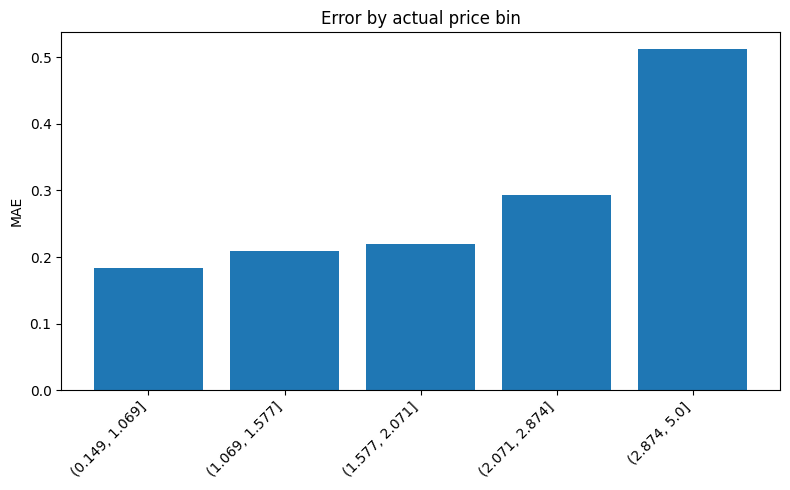

In [26]:
plt.figure(figsize=(8, 5))
plt.bar(price_bin_errors["price_bin"].astype(str), price_bin_errors["MAE"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("MAE")
plt.title("Error by actual price bin")
plt.tight_layout()
plt.show()

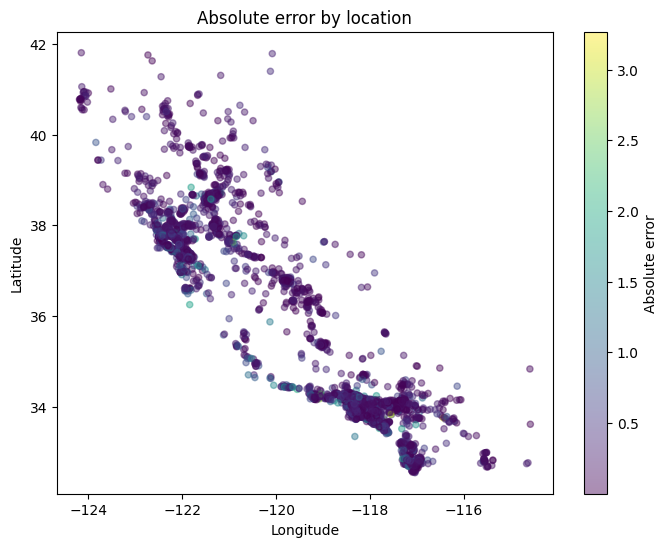

In [27]:
plt.figure(figsize=(8, 6))
scatter = plt.scatter(
    error_df["Longitude"],
    error_df["Latitude"],
    c=error_df["abs_error"],
    alpha=0.45,
    s=20
)
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Absolute error by location")
plt.colorbar(scatter, label="Absolute error")
plt.show()

# 16. Feature importance

Với RandomForest/XGBoost, ta có thể xem feature importance.  
Điều này giúp hiểu model đang dựa nhiều vào feature nào.

Lưu ý: Feature importance của tree-based model không phải lúc nào cũng là causal explanation. Nó chỉ cho biết feature nào hữu ích cho model khi split/predict.

,feature,importance
0,MedInc,0.261435
11,LogAveOccup,0.114673
9,RoomsPerPerson,0.097883
12,DistanceToSF,0.094800
7,Longitude,0.075926
6,Latitude,0.071989
5,AveOccup,0.071340
13,DistanceToLA,0.068350
8,BedroomsPerRoom,0.056581
1,HouseAge,0.032050


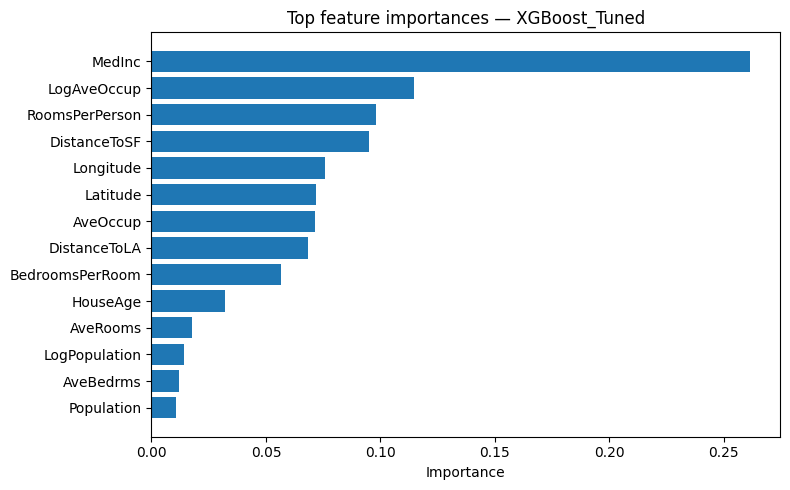

In [28]:
def get_feature_names_from_pipeline(pipeline, X_sample):
    if "features" in pipeline.named_steps:
        X_fe = pipeline.named_steps["features"].transform(X_sample)
        return list(X_fe.columns)
    return list(X_sample.columns)

model_step = best_model.named_steps.get("model", None) if hasattr(best_model, "named_steps") else None

if model_step is not None and hasattr(model_step, "feature_importances_"):
    feature_names = get_feature_names_from_pipeline(best_model, X_train)
    importances = model_step.feature_importances_

    importance_df = pd.DataFrame({
        "feature": feature_names,
        "importance": importances
    }).sort_values("importance", ascending=False)

    display(importance_df)

    plt.figure(figsize=(8, 5))
    top_imp = importance_df.head(15).sort_values("importance")
    plt.barh(top_imp["feature"], top_imp["importance"])
    plt.xlabel("Importance")
    plt.title(f"Top feature importances — {best_model_name}")
    plt.tight_layout()
    plt.show()
else:
    print("Best model không có feature_importances_. Nếu là LinearRegression, hãy xem coefficients.")

In [29]:
if model_step is not None and hasattr(model_step, "coef_"):
    feature_names = get_feature_names_from_pipeline(best_model, X_train)
    coef_df = pd.DataFrame({
        "feature": feature_names,
        "coefficient": model_step.coef_
    }).sort_values("coefficient", key=lambda s: s.abs(), ascending=False)

    display(coef_df)

# 17. Predict thử một sample mới

Ở đây ta lấy một sample từ test set để mô phỏng input mới.

In [30]:
sample = X_test.iloc[[0]].copy()
actual_value = y_test.iloc[0]
predicted_value = best_model.predict(sample)[0]

print("Sample input:")
display(sample)
print(f"Actual value:    {actual_value:.3f} x 100,000 USD")
print(f"Predicted value: {predicted_value:.3f} x 100,000 USD")
print(f"Absolute error:  {abs(actual_value - predicted_value):.3f} x 100,000 USD")

Sample input:


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
20046,1.6812,25.0,4.192201,1.022284,1392.0,3.877437,36.06,-119.01


Actual value:    0.477 x 100,000 USD
Predicted value: 0.533 x 100,000 USD
Absolute error:  0.056 x 100,000 USD


# 18. Save model và kết quả

Ta lưu:

- Best model: `models/house_price_best_model.pkl`
- Bảng kết quả: `reports/model_results.csv`
- Error analysis: `reports/error_analysis.csv`

Sau này có thể load lại model bằng `joblib.load()`.

In [32]:
BASE_DIR = Path.cwd().parent 

model_path = BASE_DIR / "models" / "houses" / "house_price_best_model.pkl"
results_path = BASE_DIR / "models" / "houses" / "model_results.csv"
error_path = BASE_DIR / "models" / "houses" / "error_analysis.csv"
metadata_path = BASE_DIR / "models" / "houses" / "model_metadata.json"

joblib.dump(best_model, model_path)
results_df.to_csv(results_path, index=False)
error_df.to_csv(error_path, index=False)

metadata = {
    "project": "Project 2 — House Price Prediction",
    "dataset": "California Housing",
    "target": "Median house value in units of 100,000 USD",
    "best_model": best_model_name,
    "metrics": results_df.iloc[0].to_dict(),
    "random_state": RANDOM_STATE
}

import json
with open(metadata_path, "w", encoding="utf-8") as f:
    json.dump(metadata, f, indent=2, ensure_ascii=False)

print("Saved model to:", model_path)
print("Saved results to:", results_path)
print("Saved error analysis to:", error_path)
print("Saved metadata to:", metadata_path)

Saved model to: c:\Users\ASUS\Documents\PROJECT\intro_to_AI\models\houses\house_price_best_model.pkl
Saved results to: c:\Users\ASUS\Documents\PROJECT\intro_to_AI\models\houses\model_results.csv
Saved error analysis to: c:\Users\ASUS\Documents\PROJECT\intro_to_AI\models\houses\error_analysis.csv
Saved metadata to: c:\Users\ASUS\Documents\PROJECT\intro_to_AI\models\houses\model_metadata.json


In [33]:
# Test load lại model
loaded_model = joblib.load(model_path)
loaded_pred = loaded_model.predict(sample)[0]
print(f"Prediction from loaded model: {loaded_pred:.3f}")

Prediction from loaded model: 0.533


# 19. Kết luận mẫu để viết report

Sau khi chạy xong notebook, bạn có thể viết report theo khung này:

## Project Summary

Project này xây dựng mô hình regression để dự đoán giá nhà California. Dataset gồm các feature về thu nhập, tuổi nhà, số phòng, dân số, occupancy và vị trí địa lý.

## EDA Findings

- Target có phân phối không hoàn toàn normal và có giới hạn ở vùng giá cao.
- `MedInc` thường có tương quan mạnh với `target`.
- `Latitude` và `Longitude` cho thấy vị trí địa lý có ảnh hưởng rõ tới giá nhà.
- Một số feature như `Population` và `AveOccup` có outliers.

## Modeling

Các model đã thử:

- Baseline median regressor
- Linear Regression
- RandomForestRegressor
- XGBoostRegressor nếu có cài thư viện

## Best Model

Model tốt nhất được chọn dựa trên test RMSE thấp nhất.

## Error Analysis

Cần quan sát:

- Model sai nhiều ở nhóm giá nào?
- Model có dự đoán thấp quá cho nhà giá cao không?
- Sai số có tập trung ở khu vực địa lý nào không?

## Next Steps

- Tune hyperparameter nhiều hơn.
- Thử target transformation như `log1p(y)`.
- Thử feature engineering nâng cao hơn từ latitude/longitude.
- So sánh model với và không xử lý outliers.

# 20. Bài tập tự luyện sau khi chạy xong

Không có đáp án sẵn trong notebook này. Bạn hãy tự thử:

1. Tắt `OutlierClipper` và so sánh metric thay đổi thế nào.
2. Xóa các feature engineering mới và so sánh với bản có feature engineering.
3. Thay tiêu chí chọn model từ RMSE sang MAE, xem best model có đổi không.
4. Tăng `n_iter` trong `RandomizedSearchCV` từ `10` lên `30`.
5. Thêm model `GradientBoostingRegressor` hoặc `ExtraTreesRegressor`.
6. Tạo report markdown riêng từ kết quả chạy được.